In [1]:

import numpy as np
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO


dataset = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="raw"
)

# create df of (n_runs, n_timepoints) eye signal
eye_signals_list = []
for subject in dataset.subjects:
    for _, run, run_df in dataset.iter_run_events(subject=subject):
        eye_signals_list.append(run_df["mreyemove"].values)

eye_signal = np.array(eye_signals_list)  # (n_runs, n_timepoints)

eye_signal.shape

(170, 427)

In [62]:
from sklearn.decomposition import PCA

n_components = 10
pca = PCA(n_components=n_components)
scores = pca.fit_transform(eye_signal)

print(f"Shape of scores: {scores.shape}")
print(f"\nVariance explained by each PC:")
for comp_idx, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{comp_idx + 1}: {var * 100:.2f}%")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
    


Shape of scores: (170, 10)

Variance explained by each PC:
  PC1: 23.77%
  PC2: 10.27%
  PC3: 6.17%
  PC4: 5.31%
  PC5: 2.90%
  PC6: 2.69%
  PC7: 2.48%
  PC8: 2.43%
  PC9: 2.22%
  PC10: 2.14%
Total variance explained: 60.38%


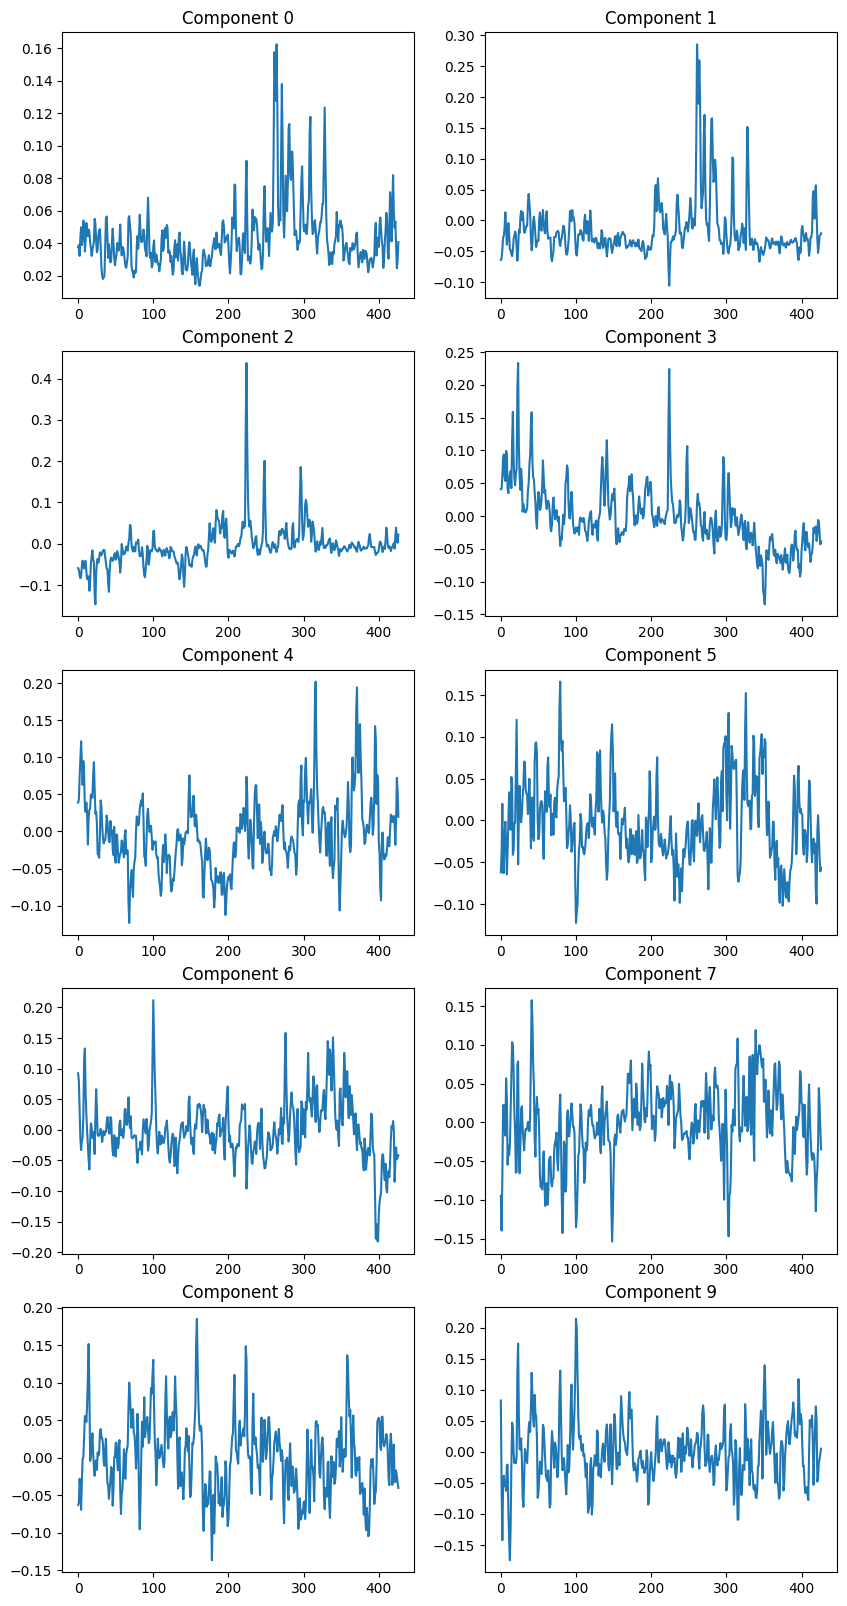

In [22]:
from matplotlib import pyplot as plt

f, axs = plt.subplots(5,2, figsize=(10,20))
axs = axs.ravel()
for comp_idx, comp in enumerate(pca.components_):
    axs[comp_idx].plot(pca.components_[comp_idx])
    axs[comp_idx].set_title(f"Component {comp_idx}")

In [63]:
import pandas as pd
import numpy as np
from mreyemove.constants import EYE_SIGNAL_CONFOUNDS
from nilearn.signal import clean

cleaned_runs = []
run_idx = 0
cleaned_dfs = []

for subject in dataset.subjects:
    for _, run, run_df in dataset.iter_run_events(subject=subject):
        run_score = scores[run_idx, :]  # (n_components,) for this run
        confounds = dataset.load_confounds(subject=subject, run=run, confound_names=EYE_SIGNAL_CONFOUNDS)
        
        # Clean confound from each scaled component
        vs = []

        for comp_idx in range(pca.n_components):
            # Scale this runs component
            signal = run_score[comp_idx] * pca.components_[comp_idx]
            signal_2d = signal.reshape(-1, 1)
            
            # Clean out motion for each scaled component
            cleaned_signal = clean(
                signal_2d,
                confounds=confounds,
                standardize=False,
                detrend=False,
                filter=False,
                t_r=None,
            ).ravel()
            vs.append(cleaned_signal)
        
        cleaned_run = np.sum(vs, axis=0) + pca.mean_
        cleaned_run_df = run_df.copy()
        cleaned_run_df["mreyemove_pca_clean"] = cleaned_run
        cleaned_dfs.append(cleaned_run_df)
        run_idx += 1

cleaned_df = pd.concat(cleaned_dfs, axis=0)


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_27977/2078140473.py:24: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  cleaned_signal = clean(
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_27977/2078140473.py:24: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  cleaned_signal = clean(
/var/folders/30/pml2mkyx


PCs most affected by motion:
       trans_x   trans_y   trans_z  trans_x_derivative1  trans_y_derivative1  \
PC3   0.008986  0.045185  0.014096             0.003076             0.001395   
PC4  -0.007780  0.012324  0.043256            -0.000121            -0.002563   
PC5  -0.020774  0.021612  0.006345            -0.000457             0.002276   
PC8  -0.033171  0.005082  0.011624            -0.001248            -0.001152   
PC12  0.004770  0.001290 -0.007950             0.004589            -0.000490   
PC7  -0.004825  0.014520  0.013660            -0.001827             0.004062   
PC1   0.018209 -0.030350  0.006250            -0.003756             0.002723   
PC16  0.003820 -0.000412 -0.002139             0.002806             0.003916   
PC9  -0.010746  0.025677 -0.000204            -0.002598             0.001038   
PC13  0.008587 -0.005232 -0.003227             0.000021             0.001888   

      trans_z_derivative1     rot_x     rot_y     rot_z  rot_x_derivative1  \
PC3        

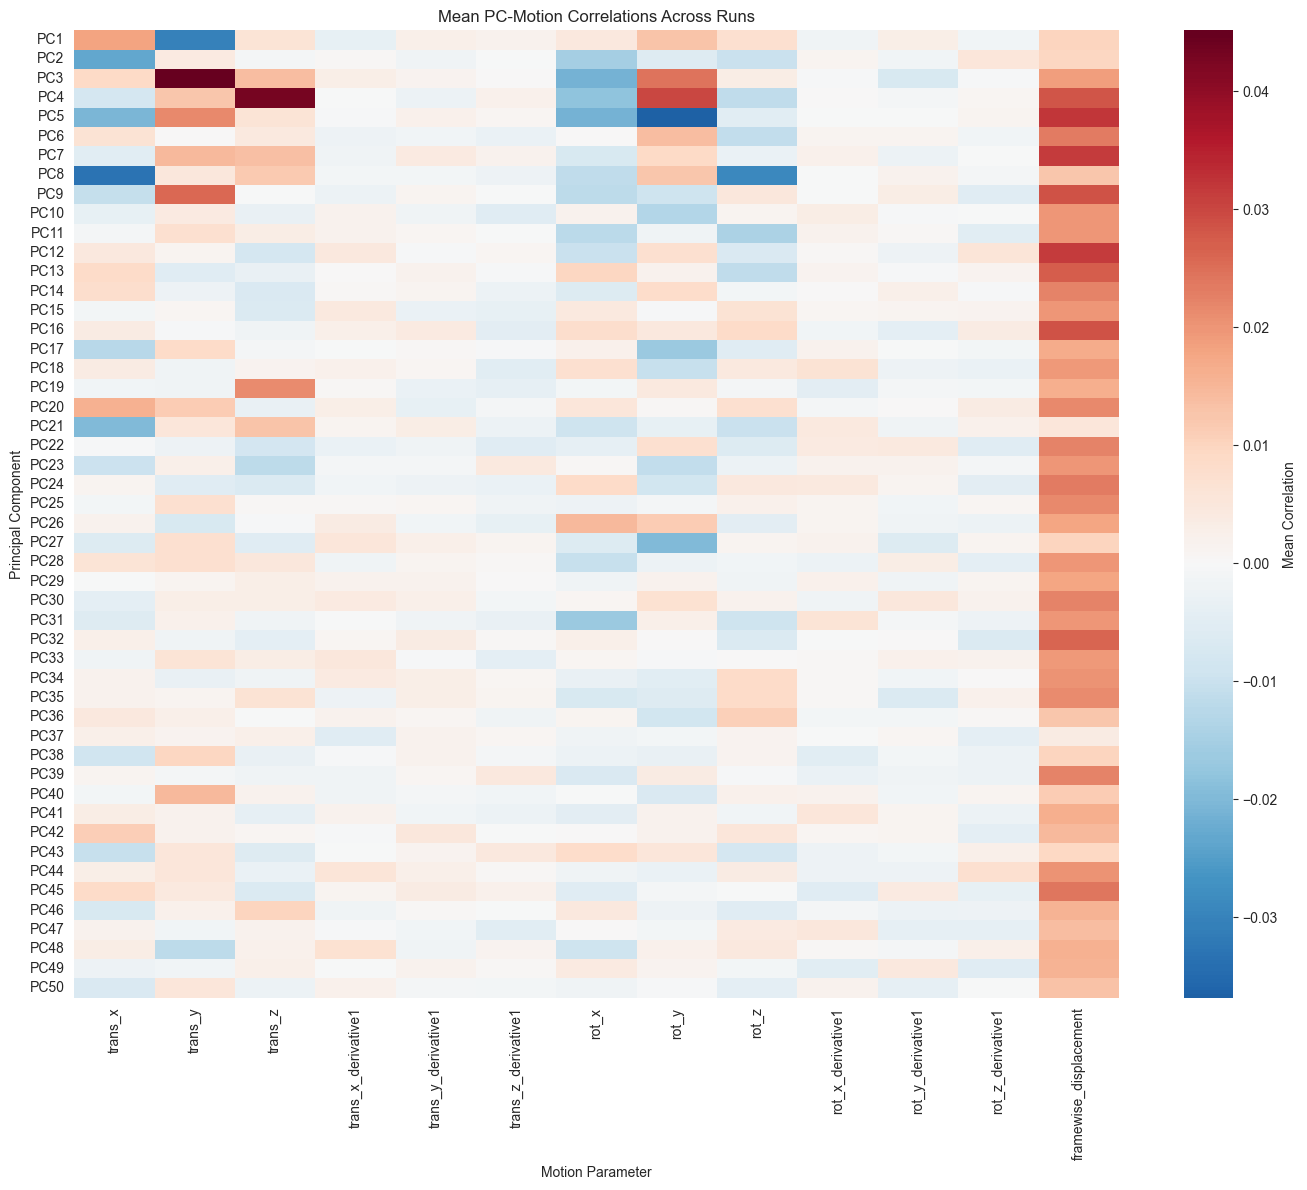

In [26]:
import pandas as pd
import numpy as np

# For each PC, collect correlations with each motion param across all runs
pc_motion_correlations = {f'PC{i+1}': {param: [] for param in EYE_SIGNAL_CONFOUNDS} 
                          for i in range(pca.n_components)}

run_idx = 0
for subject in dataset.subjects:
    for _, run, run_df in dataset.iter_run_events(subject=subject):
        confounds = dataset.load_confounds(subject=subject, run=run, confound_names=EYE_SIGNAL_CONFOUNDS)
        
        for comp_idx in range(pca.n_components):
            # Scaled PC contribution for THIS run
            pc_contribution = scores[run_idx, comp_idx] * pca.components_[comp_idx]  # (n_timepoints,)
            
            # Correlate with each motion parameter for THIS run
            for param_name in EYE_SIGNAL_CONFOUNDS:
                motion_param = confounds[param_name].values
                corr = np.corrcoef(pc_contribution, motion_param)[0, 1]
                pc_motion_correlations[f'PC{comp_idx+1}'][param_name].append(corr)
        
        run_idx += 1

# Aggregate: mean correlation across runs for each PC-parameter pair
pc_motion_summary = {}
for pc_name in pc_motion_correlations:
    pc_motion_summary[pc_name] = {
        param: np.mean((pc_motion_correlations[pc_name][param]))
        for param in EYE_SIGNAL_CONFOUNDS
    }

# Convert to DataFrame
pc_motion_df = pd.DataFrame(pc_motion_summary).T

# print("Mean correlations (PC × Motion Parameter):")
# print(pc_motion_df.head(10))

# Find most motion-affected PCs
pc_motion_df['max_abs_corr'] = pc_motion_df.abs().max(axis=1)
print("\nPCs most affected by motion:")
print(pc_motion_df.nlargest(10, 'max_abs_corr'))

# Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 12))
sns.heatmap(pc_motion_df.iloc[:50, :-1], cmap='RdBu_r', center=0, cbar_kws={'label': 'Mean Correlation'})
plt.title('Mean PC-Motion Correlations Across Runs')
plt.xlabel('Motion Parameter')
plt.ylabel('Principal Component')
plt.tight_layout()
plt.show()

In [28]:
corr_df = pc_motion_df

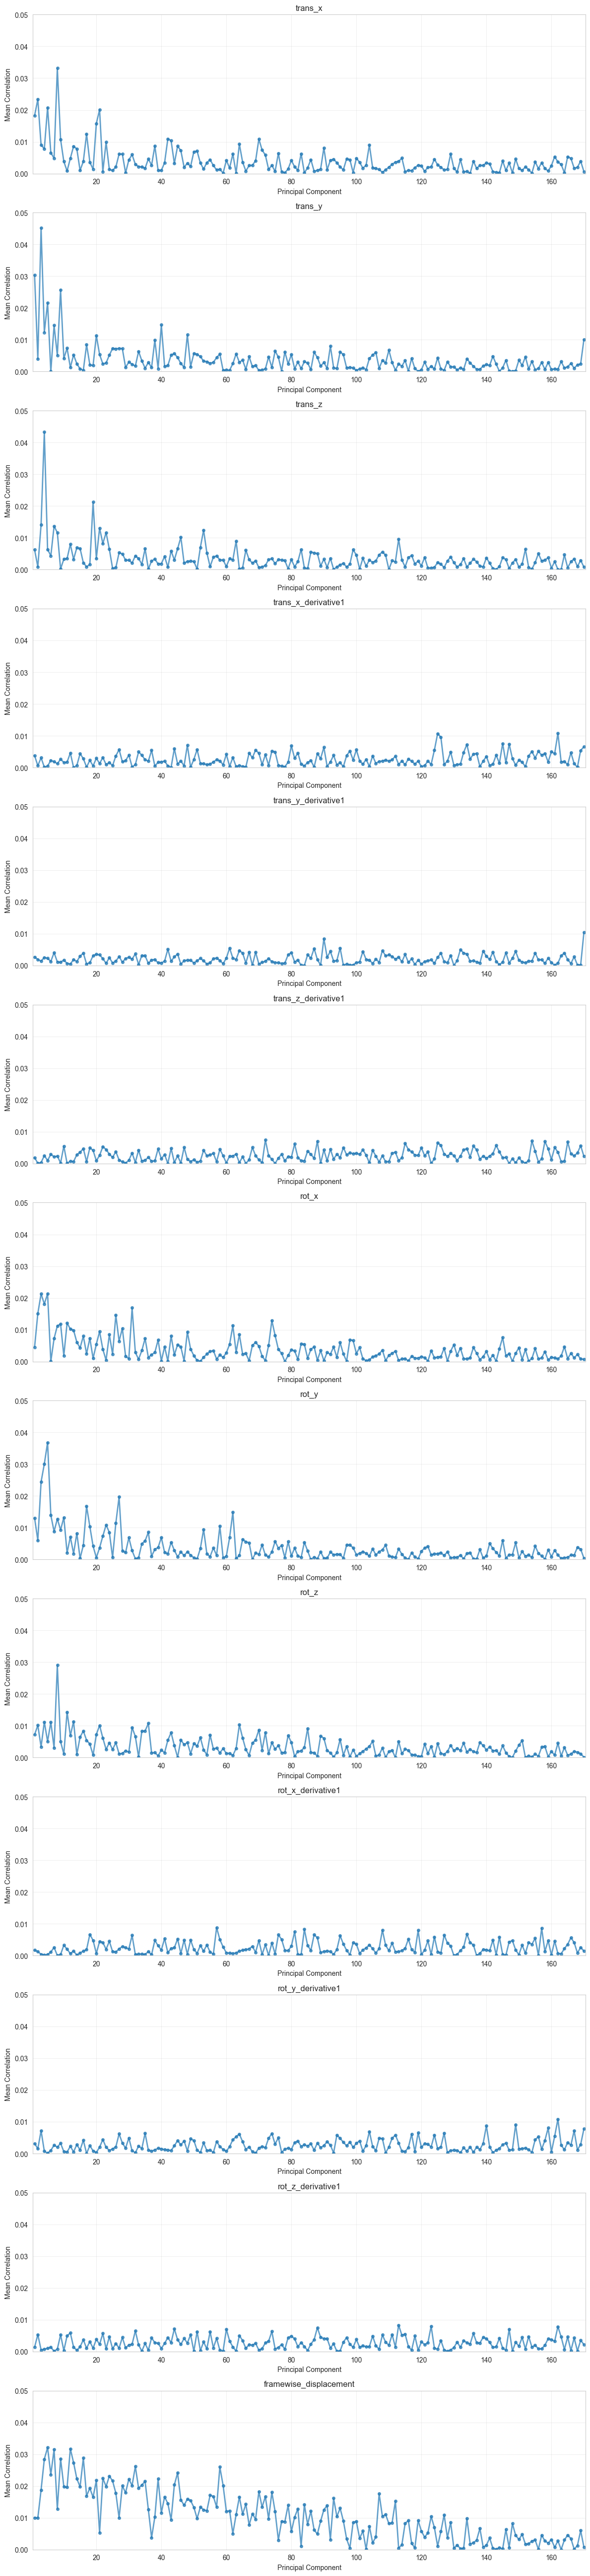

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Create subplots - one row per motion parameter
n_hmps = len(EYE_SIGNAL_CONFOUNDS)
fig, axes = plt.subplots(n_hmps, 1, figsize=(12, 4*n_hmps))

# If only one HMP, axes won't be an array
if n_hmps == 1:
    axes = [axes]

# Plot each motion parameter
for idx, hmp in enumerate(EYE_SIGNAL_CONFOUNDS):
    ax = axes[idx]
    
    # Get absolute correlations for this HMP (in original PC order)
    corrs = corr_df[hmp].abs().values
    pcs = np.arange(1, len(corrs) + 1)
    
    # Plot
    ax.plot(pcs, corrs, marker='o', linewidth=2, markersize=4, alpha=0.7)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Mean Correlation')
    ax.set_title(f'{hmp}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.5, len(corrs) + 0.5)
    ax.set_ylim(0, 0.05)

plt.tight_layout()
plt.savefig('pc_motion_abs_correlations_lines.png', dpi=150, bbox_inches='tight')
plt.show()


1. The more variance shared between components, the higher the correlation is with most HMP (not the derivatives)
2. 

In [18]:
import pandas as pd
import numpy as np

# For each HMP, find top N most correlated PCs
n_top = 10  # Number of top PCs to show

print("Top PCs by absolute correlation with each HMP:")
print("=" * 60)

top_pcs_by_hmp = {}

for hmp in EYE_SIGNAL_CONFOUNDS:
    # Get absolute correlations and sort
    abs_corrs = corr_df[hmp].abs()
    top_pcs = abs_corrs.nlargest(n_top)
    
    top_pcs_by_hmp[hmp] = top_pcs.index.tolist()
    
    print(f"\n{hmp}:")
    for i, (pc, corr) in enumerate(top_pcs.items(), 1):
        # Get variance explained by this PC
        pc_idx = int(pc.replace('PC', '')) - 1
        var_explained = pca.explained_variance_ratio_[pc_idx] * 100
        print(f"  {i}. {pc}: |r|={corr:.3f}, variance={var_explained:.2f}%")

# Find PCs that appear in top 10 for multiple HMPs
print("\n" + "=" * 60)
print("PCs appearing in top 10 for multiple HMPs:")
print("=" * 60)

all_top_pcs = []
for pcs in top_pcs_by_hmp.values():
    all_top_pcs.extend(pcs)

from collections import Counter
pc_counts = Counter(all_top_pcs)

# Sort by frequency
for pc, count in pc_counts.most_common(20):
    pc_idx = int(pc.replace('PC', '')) - 1
    var_explained = pca.explained_variance_ratio_[pc_idx] * 100
    # Show mean abs correlation across all HMPs
    mean_corr = corr_df.loc[pc].abs().mean()
    print(f"{pc}: appears in {count}/{len(EYE_SIGNAL_CONFOUNDS)} HMPs, "
          f"mean |r|={mean_corr:.3f}, variance={var_explained:.2f}%")

# Create a summary DataFrame showing top 5 PCs for each HMP
print("\n" + "=" * 60)
print("Summary table (top 5 PCs per HMP):")
print("=" * 60)

summary_data = {}
for hmp in EYE_SIGNAL_CONFOUNDS:
    abs_corrs = corr_df[hmp].abs()
    top_5 = abs_corrs.nlargest(5)
    summary_data[hmp] = [f"{pc} ({corr:.2f})" for pc, corr in top_5.items()]

summary_df = pd.DataFrame(summary_data)
print(summary_df.T)  # Transpose so HMPs are rows

Top PCs by absolute correlation with each HMP:

trans_x:
  1. PC8: |r|=0.033, variance=2.43%
  2. PC2: |r|=0.023, variance=10.27%
  3. PC5: |r|=0.021, variance=2.90%
  4. PC21: |r|=0.020, variance=1.10%
  5. PC1: |r|=0.018, variance=23.77%
  6. PC20: |r|=0.016, variance=1.22%
  7. PC17: |r|=0.012, variance=1.39%
  8. PC42: |r|=0.011, variance=0.39%
  9. PC70: |r|=0.011, variance=0.12%
  10. PC9: |r|=0.011, variance=2.22%

trans_y:
  1. PC3: |r|=0.045, variance=6.17%
  2. PC1: |r|=0.030, variance=23.77%
  3. PC9: |r|=0.026, variance=2.22%
  4. PC5: |r|=0.022, variance=2.90%
  5. PC40: |r|=0.015, variance=0.43%
  6. PC7: |r|=0.015, variance=2.48%
  7. PC4: |r|=0.012, variance=5.31%
  8. PC48: |r|=0.012, variance=0.29%
  9. PC20: |r|=0.011, variance=1.22%
  10. PC170: |r|=0.010, variance=0.00%

trans_z:
  1. PC4: |r|=0.043, variance=5.31%
  2. PC19: |r|=0.021, variance=1.30%
  3. PC3: |r|=0.014, variance=6.17%
  4. PC7: |r|=0.014, variance=2.48%
  5. PC21: |r|=0.013, variance=1.10%
  6. P

In [35]:
# R² is always positive and doesn't have sign issues
hmp_comp_r2 = {hmp: [] for hmp in EYE_SIGNAL_CONFOUNDS}

run_idx = 0
for subject in dataset.subjects:
    for _, run, run_df in dataset.iter_run_events(subject=subject):
        confounds = dataset.load_confounds(subject=subject, run=run, confound_names=EYE_SIGNAL_CONFOUNDS)
        
        for comp_idx in range(pca.n_components):
            signal = scores[run_idx, comp_idx] * pca.components_[comp_idx]
            
            for hmp in EYE_SIGNAL_CONFOUNDS:
                confound = confounds[hmp]
                r2 = np.corrcoef(confound, signal)[0, 1] ** 2  # Square the correlation
                hmp_comp_r2[hmp].append(r2)
        
        run_idx += 1

# Reshape and get mean R²
r2_df_dict = {}
for hmp in EYE_SIGNAL_CONFOUNDS:
    r2s = np.array(hmp_comp_r2[hmp]).reshape(run_idx, pca.n_components)
    r2_df_dict[hmp] = np.mean(r2s, axis=0)

r2_df = pd.DataFrame(r2_df_dict, index=[f'PC{i+1}' for i in range(pca.n_components)])
print("\nMean R² (variance explained):")
print(r2_df.head(10))


Mean R² (variance explained):
       trans_x   trans_y   trans_z  trans_x_derivative1  trans_y_derivative1  \
PC1   0.037121  0.017850  0.038541             0.000742             0.000319   
PC2   0.019226  0.007701  0.017214             0.000685             0.000470   
PC3   0.058795  0.034784  0.059392             0.000653             0.000555   
PC4   0.112455  0.083982  0.138799             0.000747             0.000341   
PC5   0.031976  0.017311  0.029943             0.001095             0.000352   
PC6   0.016606  0.009656  0.019707             0.001041             0.000590   
PC7   0.019504  0.010019  0.022030             0.001026             0.000547   
PC8   0.021096  0.010201  0.024339             0.001200             0.000773   
PC9   0.016322  0.009933  0.018627             0.001025             0.000551   
PC10  0.005186  0.003258  0.004707             0.001437             0.000846   

      trans_z_derivative1     rot_x     rot_y     rot_z  rot_x_derivative1  \
PC1       

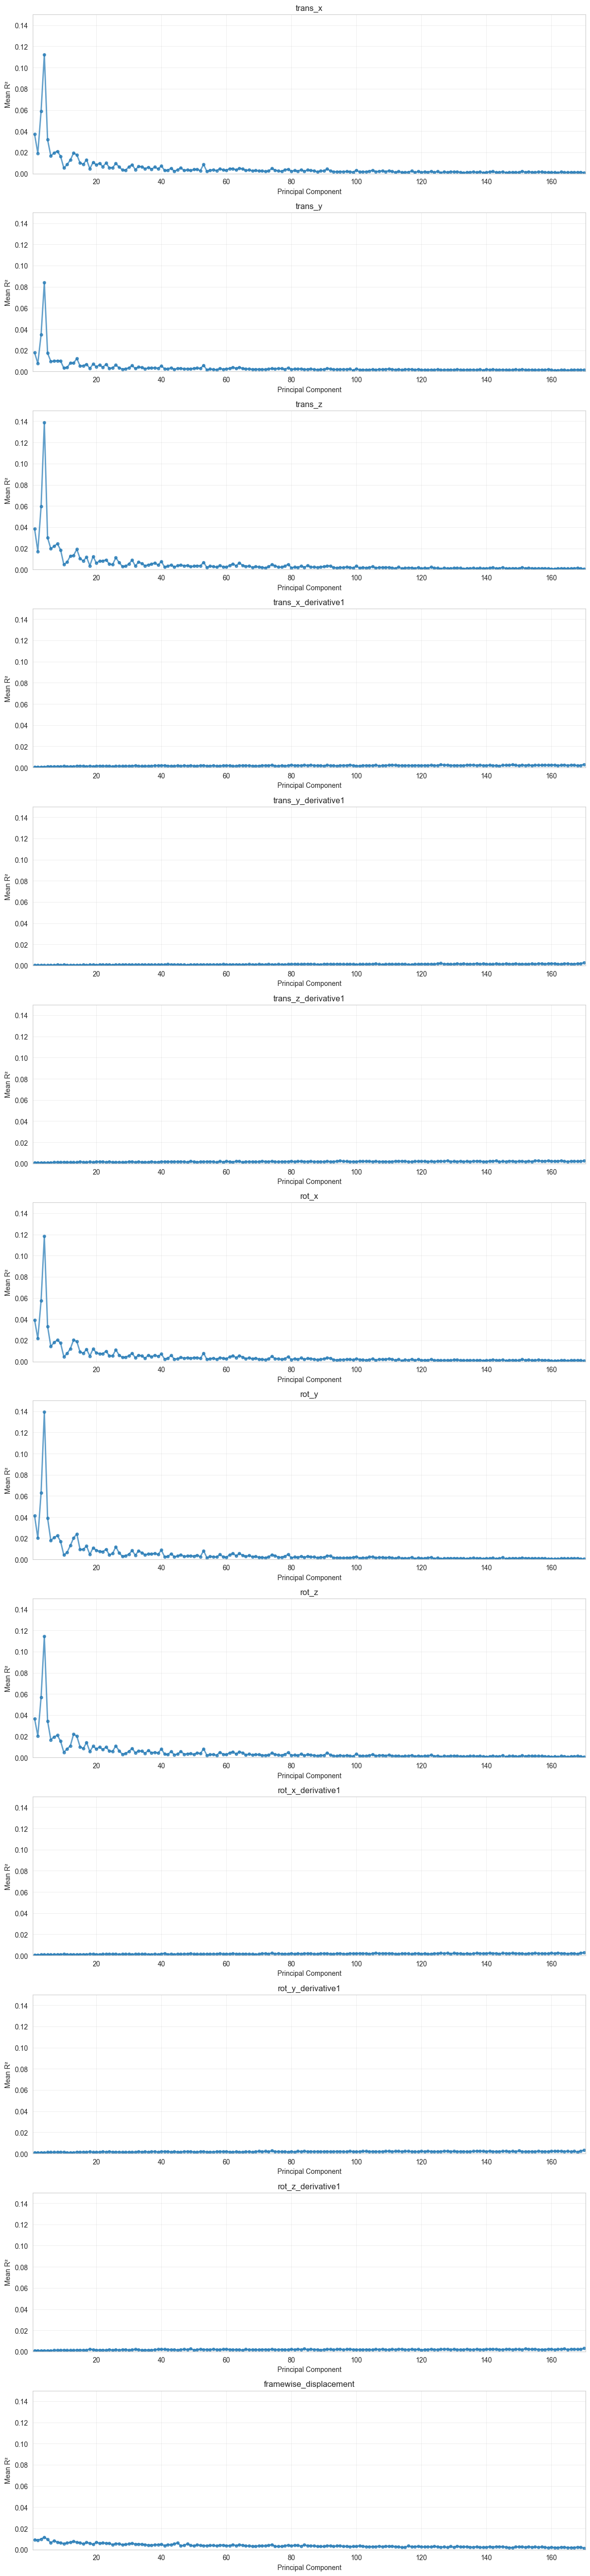

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Create subplots - one row per motion parameter
n_hmps = len(EYE_SIGNAL_CONFOUNDS)
fig, axes = plt.subplots(n_hmps, 1, figsize=(12, 4*n_hmps))

# If only one HMP, axes won't be an array
if n_hmps == 1:
    axes = [axes]

# Plot each motion parameter
for idx, hmp in enumerate(EYE_SIGNAL_CONFOUNDS):
    ax = axes[idx]
    
    # Get R² for this HMP (in original PC order)
    r2_values = r2_df[hmp].values
    pcs = np.arange(1, len(r2_values) + 1)
    
    # Plot
    ax.plot(pcs, r2_values, marker='o', linewidth=2, markersize=4, alpha=0.7)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Mean R²')
    ax.set_title(f'{hmp}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.5, len(r2_values) + 0.5)
    ax.set_ylim(0, 0.15)  # R² starts at 0

plt.tight_layout()
plt.savefig('pc_motion_r2_lines.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Find top PCs by R² for each HMP
n_top = 10

print("Top PCs by R² with each HMP:")
print("=" * 60)

for hmp in EYE_SIGNAL_CONFOUNDS:
    # Get R² and sort
    r2_values = r2_df[hmp]
    top_pcs = r2_values.nlargest(n_top)
    
    print(f"\n{hmp}:")
    for i, (pc, r2) in enumerate(top_pcs.items(), 1):
        # Get variance explained by this PC
        pc_idx = int(pc.replace('PC', '')) - 1
        var_explained = pca.explained_variance_ratio_[pc_idx] * 100
        print(f"  {i}. {pc}: R²={r2:.3f}, variance={var_explained:.2f}%")

Top PCs by R² with each HMP:

trans_x:
  1. PC4: R²=0.112, variance=5.31%
  2. PC3: R²=0.059, variance=6.17%
  3. PC1: R²=0.037, variance=23.77%
  4. PC5: R²=0.032, variance=2.90%
  5. PC8: R²=0.021, variance=2.43%
  6. PC7: R²=0.020, variance=2.48%
  7. PC13: R²=0.019, variance=1.71%
  8. PC2: R²=0.019, variance=10.27%
  9. PC14: R²=0.018, variance=1.60%
  10. PC6: R²=0.017, variance=2.69%

trans_y:
  1. PC4: R²=0.084, variance=5.31%
  2. PC3: R²=0.035, variance=6.17%
  3. PC1: R²=0.018, variance=23.77%
  4. PC5: R²=0.017, variance=2.90%
  5. PC14: R²=0.012, variance=1.60%
  6. PC8: R²=0.010, variance=2.43%
  7. PC7: R²=0.010, variance=2.48%
  8. PC9: R²=0.010, variance=2.22%
  9. PC6: R²=0.010, variance=2.69%
  10. PC12: R²=0.008, variance=1.86%

trans_z:
  1. PC4: R²=0.139, variance=5.31%
  2. PC3: R²=0.059, variance=6.17%
  3. PC1: R²=0.039, variance=23.77%
  4. PC5: R²=0.030, variance=2.90%
  5. PC8: R²=0.024, variance=2.43%
  6. PC7: R²=0.022, variance=2.48%
  7. PC6: R²=0.020, v

In [56]:

dataset_clean = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean"
)

In [54]:
corrs = [ ]
for subject in dataset_clean.subjects:
    for _, run, run_df in dataset_clean.iter_run_events(subject=subject):
        orig_clean = run_df["mreyemove"]
        
        cleaned_run_df = cleaned_df[(cleaned_df["subject"] == subject) & (cleaned_df["run"] == int(run))].reset_index(drop=True)
        pca_clean = cleaned_run_df["mreyemove_pca_clean"]
        
        corrs.append(np.corrcoef(orig_clean, pca_clean)[0,1])
        
print(f"Mean correlation clean vs pca_clean {np.mean(corrs)}")

Mean correlation clean vs pca_clean 0.9630452601124626


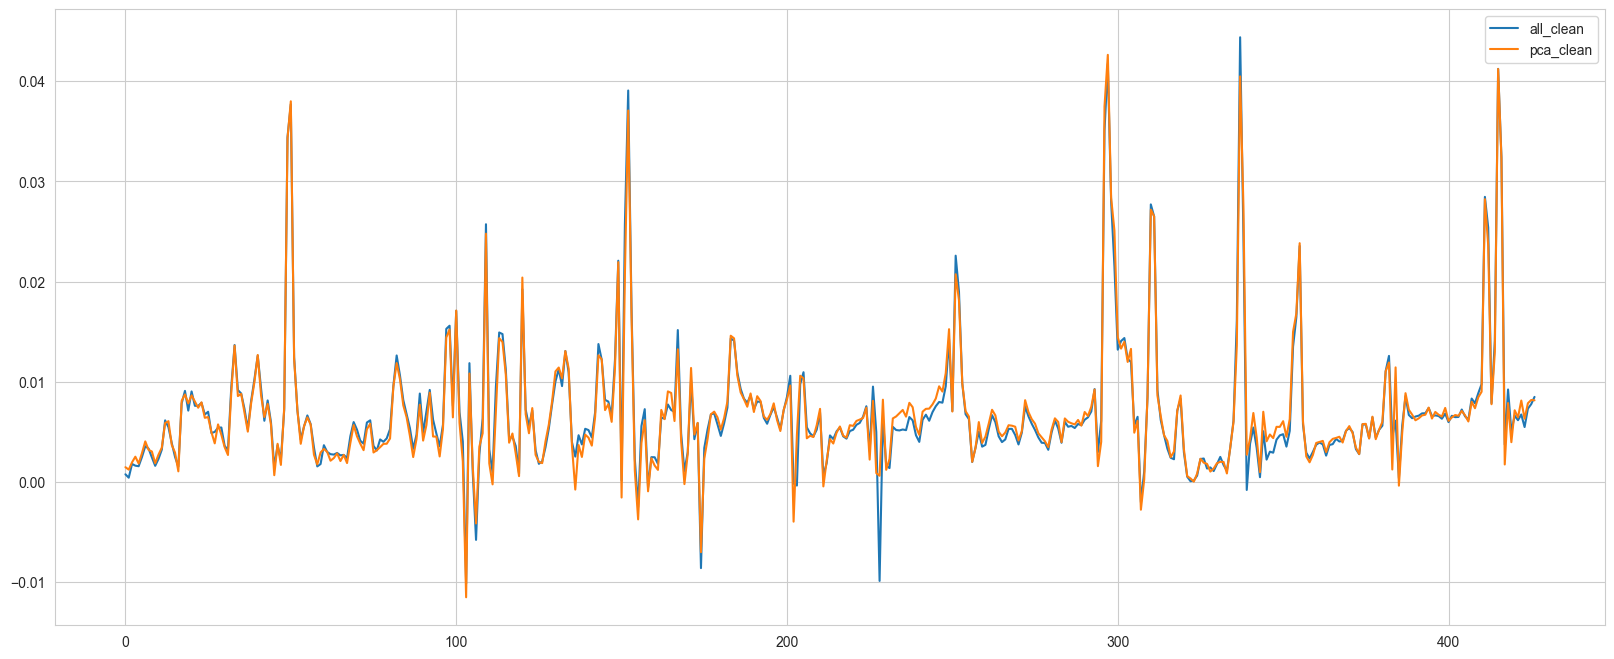

In [59]:
subject = "03"
run = "8"

cleaned_run_df = cleaned_df[(cleaned_df["subject"] == subject) & (cleaned_df["run"] == int(run))].reset_index(drop=True)
pca_clean = cleaned_run_df["mreyemove_pca_clean"]
all_clean, _ = dataset_clean.load_eye_move(subject=subject, run=run, desc_add="clean")

f, ax = plt.subplots(1,1,figsize=(20, 8))

ax.plot(all_clean, label="all_clean")
ax.plot(pca_clean, label="pca_clean")

ax.legend()


In [47]:
all_clean.shape

AttributeError: 'tuple' object has no attribute 'shape'